#### Dataset Collection



In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gauravmalik26/food-delivery-dataset")

print("Path to dataset files:", path)

e:\food-delivery-prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Azrap\.cache\kagglehub\datasets\gauravmalik26\food-delivery-dataset\versions\1


In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)

# to get all the columns

In [3]:
import os

os.listdir(path)

['Sample_Submission.csv', 'test.csv', 'train.csv']

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

train=pd.read_csv(os.path.join(path,'train.csv'))


In [5]:
train.shape # there aer 45593 rows and 20 columns

(45593, 20)

In [6]:
train.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  str    
 3   Delivery_person_Ratings      45593 non-null  str    
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  45593 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

In [8]:
# the nan values were in the string thats why with isnull function we didnt got any missing values

train = train.replace(r"^\s*NaN\s*$", np.nan, regex=True)


In [9]:
train.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

In [10]:
# dropping unnecessary columns

drop_cols=['ID','Delivery_person_ID']

train.drop(drop_cols,axis=1,inplace=True)


In [11]:
train.columns=train.columns.str.lower().str.strip()


In [12]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   delivery_person_age          43739 non-null  str    
 1   delivery_person_ratings      43685 non-null  str    
 2   restaurant_latitude          45593 non-null  float64
 3   restaurant_longitude         45593 non-null  float64
 4   delivery_location_latitude   45593 non-null  float64
 5   delivery_location_longitude  45593 non-null  float64
 6   order_date                   45593 non-null  str    
 7   time_orderd                  43862 non-null  str    
 8   time_order_picked            45593 non-null  str    
 9   weatherconditions            45593 non-null  str    
 10  road_traffic_density         44992 non-null  str    
 11  vehicle_condition            45593 non-null  int64  
 12  type_of_order                45593 non-null  str    
 13  type_of_vehicle            

In [13]:
## Convert Columns to Numeric

train['delivery_person_age'] = pd.to_numeric(
    train['delivery_person_age'],
    errors='coerce'
)

train['delivery_person_ratings'] = pd.to_numeric(
    train['delivery_person_ratings'],
    errors='coerce'
)

train['multiple_deliveries'] = pd.to_numeric(
    train['multiple_deliveries'],
    errors='coerce'
)


In [14]:
## Convert Columns to Date time
train["order_date"] = pd.to_datetime(
    train["order_date"],
    format="%d-%m-%Y",
    errors="coerce"
)

train["time_orderd"] = pd.to_datetime(
    train["time_orderd"],
    format="%H:%M:%S",
    errors="coerce"
)



In [15]:

train["time_order_picked"] = pd.to_datetime(
    train["time_order_picked"],
    format="%H:%M:%S",
    errors="coerce"
)


In [16]:
train['time_order_picked_hr']=train['time_order_picked'].dt.hour
train['time_order_picked_mins']=train['time_order_picked'].dt.minute

train.drop('time_order_picked',axis=1,inplace=True)

In [17]:
train.head(2)

,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_orderd,weatherconditions,road_traffic_density,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_taken(min),time_order_picked_hr,time_order_picked_mins
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,1900-01-01 11:30:00,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,(min) 24,11,45
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,1900-01-01 19:45:00,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,(min) 33,19,50


In [18]:
train['time_taken_mins']=train['time_taken(min)'].str.extract(r'(\d+)') # to extract only the digits from the column

In [19]:
train.drop('time_taken(min)',axis=1,inplace=True)

In [20]:
train['time_taken_mins'] = pd.to_numeric(
    train['time_taken_mins'],
    errors='coerce'
)

In [21]:
train.isnull().sum()

delivery_person_age            1854
delivery_person_ratings        1908
restaurant_latitude               0
restaurant_longitude              0
delivery_location_latitude        0
delivery_location_longitude       0
order_date                        0
time_orderd                    1731
weatherconditions                 0
road_traffic_density            601
vehicle_condition                 0
type_of_order                     0
type_of_vehicle                   0
multiple_deliveries             993
festival                        228
city                           1200
time_order_picked_hr              0
time_order_picked_mins            0
time_taken_mins                   0
dtype: int64

In [22]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   delivery_person_age          43739 non-null  float64       
 1   delivery_person_ratings      43685 non-null  float64       
 2   restaurant_latitude          45593 non-null  float64       
 3   restaurant_longitude         45593 non-null  float64       
 4   delivery_location_latitude   45593 non-null  float64       
 5   delivery_location_longitude  45593 non-null  float64       
 6   order_date                   45593 non-null  datetime64[us]
 7   time_orderd                  43862 non-null  datetime64[us]
 8   weatherconditions            45593 non-null  str           
 9   road_traffic_density         44992 non-null  str           
 10  vehicle_condition            45593 non-null  int64         
 11  type_of_order                45593 non-null  str    

In [23]:
train['time_orderd_hr']=train['time_orderd'].dt.hour
train['time_orderd_mins']=train['time_orderd'].dt.minute


In [24]:
train.drop('time_orderd',axis=1,inplace=True)

In [25]:
# so instead of givign the entrieorder date column we will extract the imp features from it

# beuase raw date column is nothing to the model
# but the week day? the month and all thiss carries importance...

train['orderd_day_of_week']=train['order_date'].dt.day_of_week
train['orderd_month'] = train['order_date'].dt.month
train['orderd_is_weekend']=train['orderd_day_of_week'].isin([5,6]).astype(int) # means 5->sat 6->sun so is weekend


In [26]:
train.drop('order_date',axis=1,inplace=True)

In [27]:
# function to find the distance km betwenn restaurant ad delivery location

from math import radians, sin, cos, sqrt, atan2

def calculate_distance(row):
    lat1 = radians(row['restaurant_latitude'])
    lon1 = radians(row['restaurant_longitude'])
    lat2 = radians(row['delivery_location_latitude'])
    lon2 = radians(row['delivery_location_longitude'])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return 6371 * c

train['distance_km']=train.apply(calculate_distance, axis=1)

In [28]:
train.drop(['restaurant_latitude','restaurant_longitude','delivery_location_latitude','delivery_location_longitude'],axis=1,inplace=True)


In [29]:
cat_cols=[i for i in train.columns if train[i].dtypes=='O']
cat_cols

[]

In [30]:
for i in cat_cols:
  print(i," : ",train[i].unique())
  print("**"*20)

In [31]:
for i in cat_cols:
  train[i]=train[i].str.strip()

In [32]:


train['weatherconditions'] = train['weatherconditions'].replace('conditions NaN', np.nan)

In [33]:
for i in cat_cols:
  print(i," : ",train[i].unique())
  print("**"*20)

In [34]:
train[cat_cols].isnull().sum()

Series([], dtype: float64)

In [35]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   delivery_person_age      43739 non-null  float64
 1   delivery_person_ratings  43685 non-null  float64
 2   weatherconditions        44977 non-null  str    
 3   road_traffic_density     44992 non-null  str    
 4   vehicle_condition        45593 non-null  int64  
 5   type_of_order            45593 non-null  str    
 6   type_of_vehicle          45593 non-null  str    
 7   multiple_deliveries      44600 non-null  float64
 8   festival                 45365 non-null  str    
 9   city                     44393 non-null  str    
 10  time_order_picked_hr     45593 non-null  int32  
 11  time_order_picked_mins   45593 non-null  int32  
 12  time_taken_mins          45593 non-null  int64  
 13  time_orderd_hr           43862 non-null  float64
 14  time_orderd_mins         43862 no

In [36]:
num_cols=[i for i in train.columns if train[i].dtypes!='O']
num_cols

['delivery_person_age',
 'delivery_person_ratings',
 'weatherconditions',
 'road_traffic_density',
 'vehicle_condition',
 'type_of_order',
 'type_of_vehicle',
 'multiple_deliveries',
 'festival',
 'city',
 'time_order_picked_hr',
 'time_order_picked_mins',
 'time_taken_mins',
 'time_orderd_hr',
 'time_orderd_mins',
 'orderd_day_of_week',
 'orderd_month',
 'orderd_is_weekend',
 'distance_km']

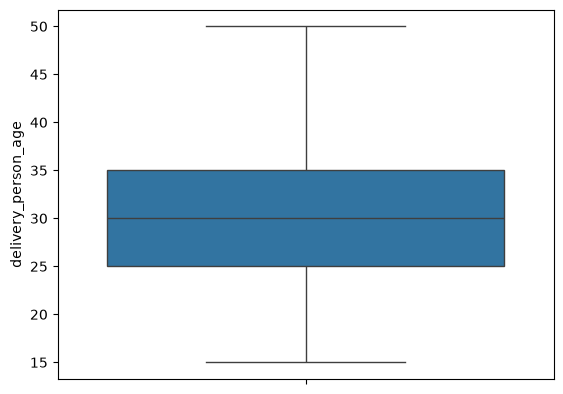

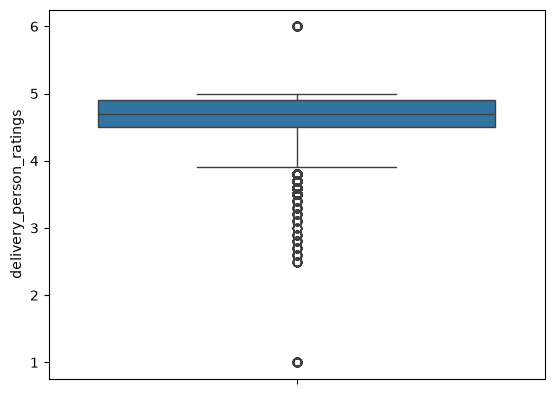

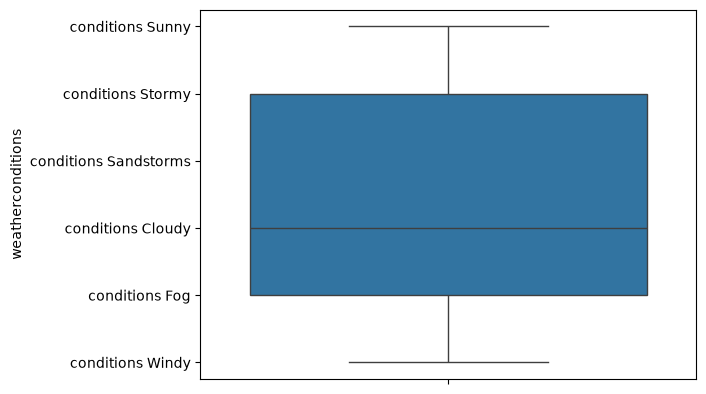

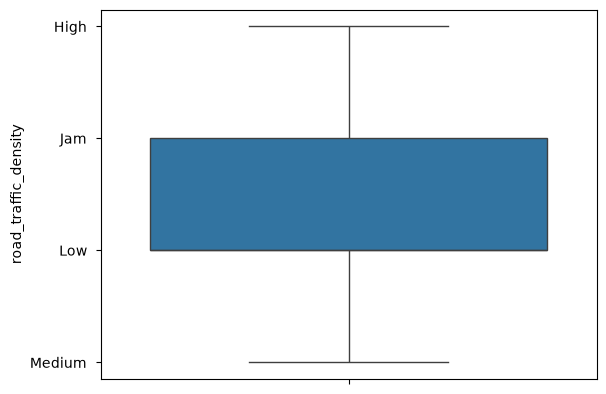

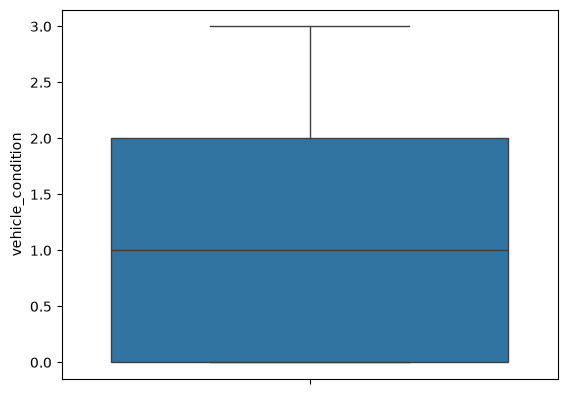

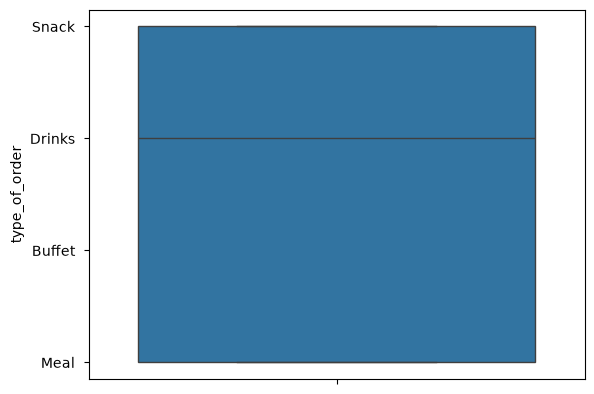

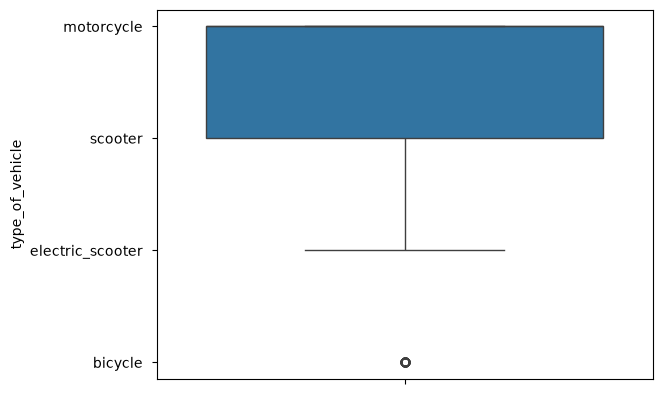

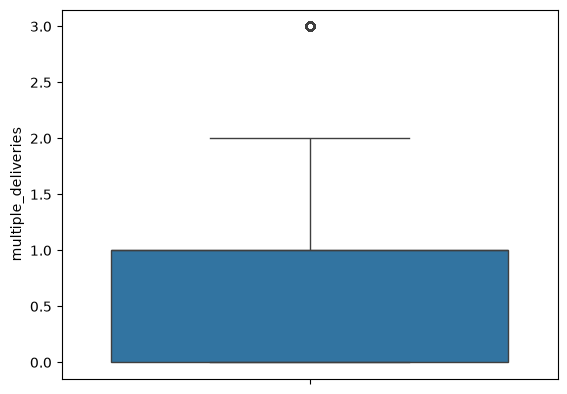

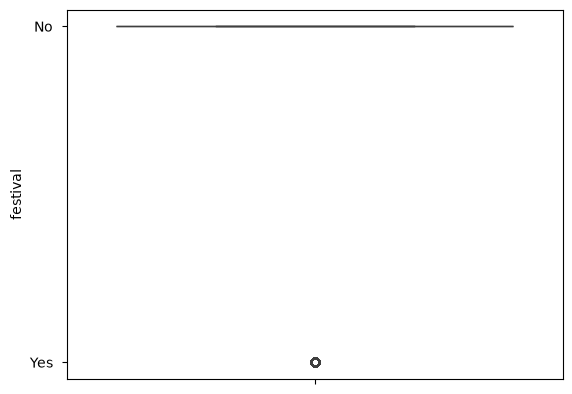

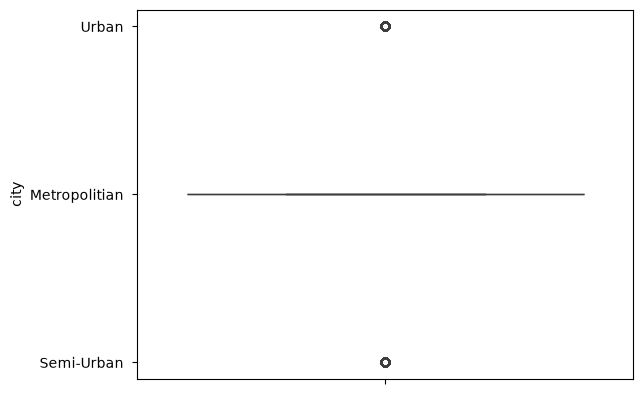

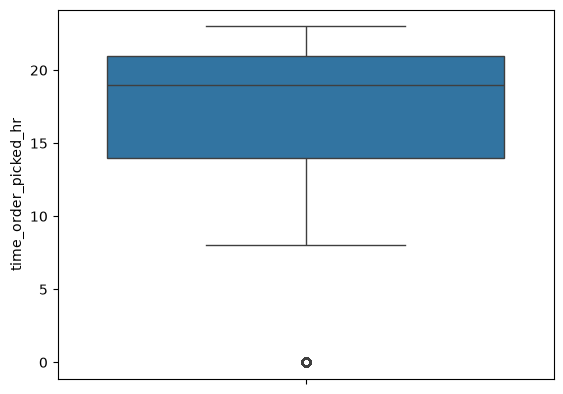

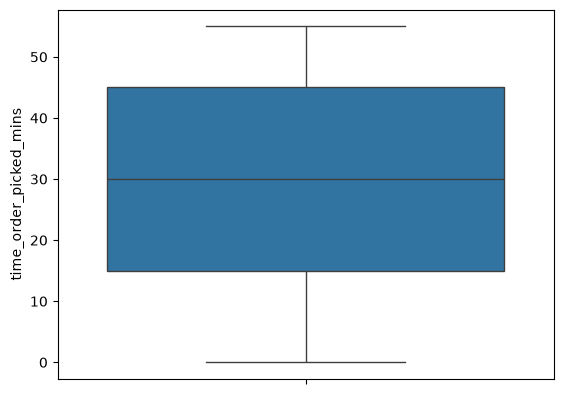

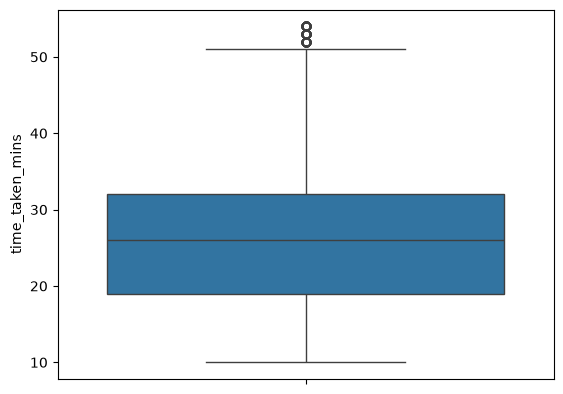

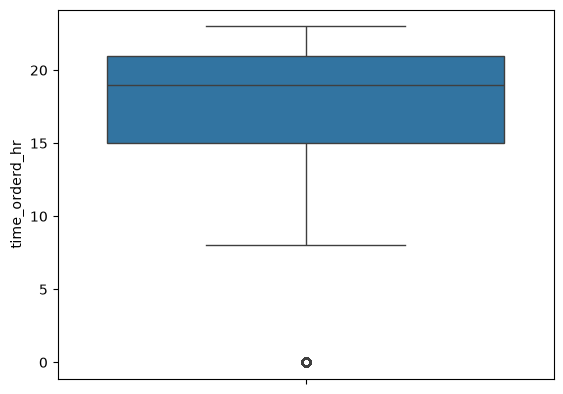

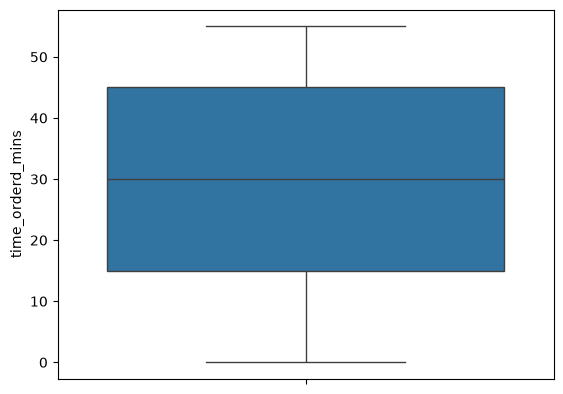

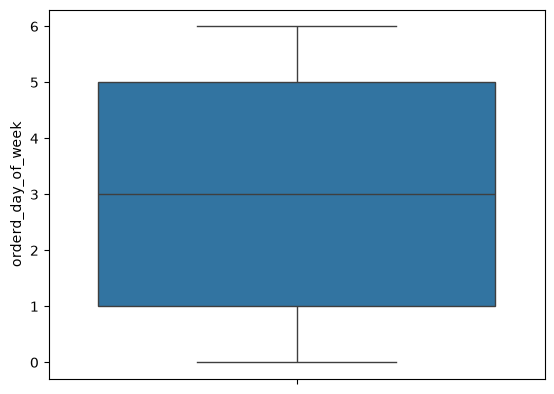

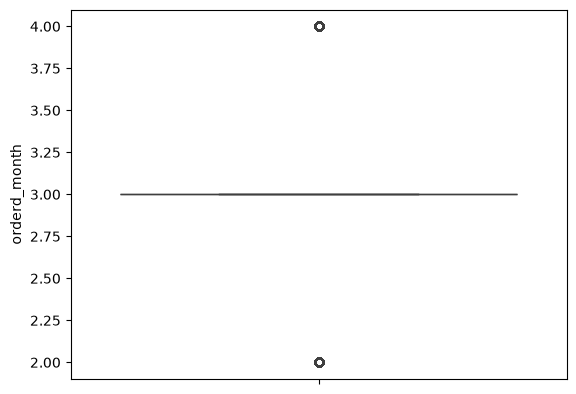

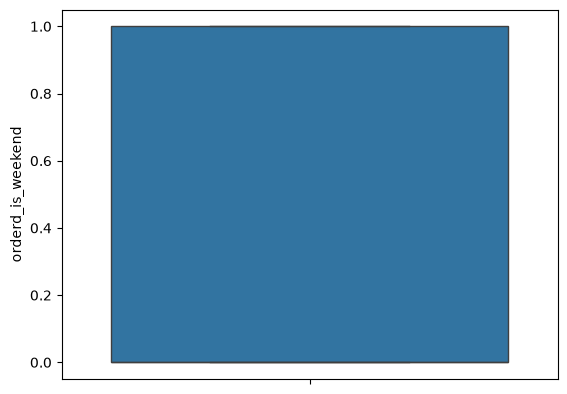

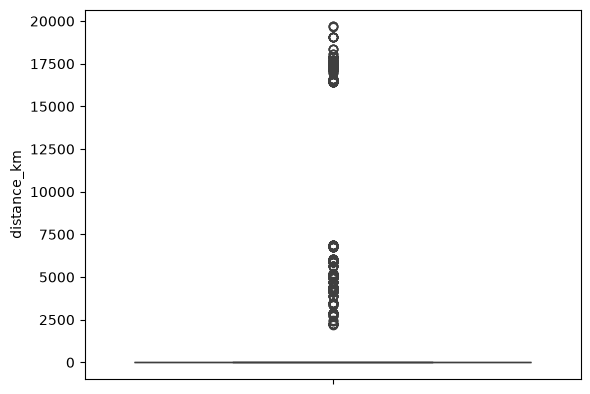

In [37]:
# to check the outliers in the num cols
for i in num_cols:
  sns.boxplot(train[i])
  plt.show()

In [38]:
train['delivery_person_ratings'] = train['delivery_person_ratings'].clip(upper=5)


In [39]:
train['festival']=train['festival'].map({'Yes':1,'No':0})

In [40]:
cat_cols = train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
for col in cat_cols:
    train[col] = train[col].str.strip()

train['weatherconditions'] = train['weatherconditions'].replace('conditions NaN', np.nan)
train['festival'] = train['festival'].map({'Yes': 1, 'No': 0})

#### Splitting the data

In [41]:
X=train.drop('time_taken_mins',axis=1)
y=train['time_taken_mins']

In [42]:
#split the data into

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [43]:
X_train.shape

(36474, 18)

In [44]:
y_train.shape

(36474,)

#### Base Model Training

In [45]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

#impute+scaling
num_cols = [
    'delivery_person_age',
    'delivery_person_ratings',
    'time_order_picked_hr',
    'time_order_picked_mins',
    'time_orderd_hr',
    'time_orderd_mins',
    'orderd_day_of_week',
    'orderd_month',
    'orderd_is_weekend',
    'distance_km'
]

#impute+ohe
cat_cols_ohe = [
    'weatherconditions',
    'type_of_order',
    'type_of_vehicle',
    'city'
]

#impute+ordinal
cat_cols_ordinal=['road_traffic_density']

#impute
no_encoding_int = [
    'vehicle_condition',
    'multiple_deliveries',
    'festival'
]


num_impute_scaling_pipeline=Pipeline([
    ("impute",SimpleImputer(strategy='median')),
    ("scaling",StandardScaler())
])

cat_impute_ohe_pipeline=Pipeline([
    ("impute",SimpleImputer(strategy='most_frequent')),
    ("ohe",OneHotEncoder(handle_unknown='ignore'))
])

cat_impute_ordinal_pipeline=Pipeline([
    ("impute",SimpleImputer(strategy='most_frequent')),
    ("ordinal", OrdinalEncoder(
        categories=[['Low', 'Medium', 'High', 'Jam']]
    ))
])

num_impute_pipeline=Pipeline([
    ("impute",SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer([
    ("num", num_impute_scaling_pipeline, num_cols),
    ("ohe", cat_impute_ohe_pipeline, cat_cols_ohe),
    ("ordinal", cat_impute_ordinal_pipeline, cat_cols_ordinal),
    ("no_encoding", num_impute_pipeline, no_encoding_int)
])


In [46]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

trained_models = {}

for name, model in models.items():

    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    model_pipeline.fit(X_train, y_train)

    y_pred = model_pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    trained_models[name] = model_pipeline

    print(f"\n{name}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")

e:\food-delivery-prediction\venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['festival']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
e:\food-delivery-prediction\venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['festival']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(



Linear Regression
MAE  : 5.13
RMSE : 6.46
R²   : 0.5233


e:\food-delivery-prediction\venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['festival']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
e:\food-delivery-prediction\venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['festival']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
e:\food-delivery-prediction\venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['festival']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(



Decision Tree
MAE  : 4.25
RMSE : 5.60
R²   : 0.6422


e:\food-delivery-prediction\venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['festival']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(



Random Forest
MAE  : 3.23
RMSE : 4.06
R²   : 0.8121


e:\food-delivery-prediction\venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['festival']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(



Gradient Boosting
MAE  : 3.69
RMSE : 4.62
R²   : 0.7568


e:\food-delivery-prediction\venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['festival']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


#### Hyper Parameter Tuning

In [48]:
import warnings, os
warnings.filterwarnings("ignore")

In [49]:
from sklearn.model_selection import GridSearchCV

params = {
    "decision_tree": {
        "max_depth": [5, 10, 15, 20, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": [None, "sqrt", "log2"]
    },

    "random_forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [10, 20, 30, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", None]
    },

    "gradient_boosting": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [2, 3, 5],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "subsample": [0.8, 1.0]
    }
}

selected_models = {
    "decision_tree": DecisionTreeRegressor(random_state=42),
    "random_forest": RandomForestRegressor(random_state=42),
    "gradient_boosting": GradientBoostingRegressor(random_state=42)
}

results = {}

for name, model in selected_models.items():

    grid = GridSearchCV(
        estimator=model,
        param_grid=params[name],
        scoring='neg_mean_absolute_error',
        cv=5,
        n_jobs=-1
    )

    final_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", grid)
    ])

    # Train
    final_pipeline.fit(X_train, y_train)

    # Prediction on validation data
    y_pred = final_pipeline.predict(X_test)

    # Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Best Parameters": grid.best_params_
    }

    print(f"\n{name.upper()}")
    print("-" * 40)
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    print("Best Parameters:")
    print(grid.best_params_)


DECISION_TREE
----------------------------------------
MAE  : 3.34
RMSE : 4.23
R²   : 0.7961
Best Parameters:
{'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10}

RANDOM_FOREST
----------------------------------------
MAE  : 3.21
RMSE : 4.03
R²   : 0.8146
Best Parameters:
{'max_depth': 20, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}

GRADIENT_BOOSTING
----------------------------------------
MAE  : 3.27
RMSE : 4.10
R²   : 0.8080
Best Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200, 'subsample': 1.0}


In [50]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42, n_jobs=1, tree_method="hist"))
])

xgb_params = {
    "model__n_estimators": [50, 100, 200, 400, 600],
    "model__learning_rate": [0.03, 0.05, 0.1,0.01],
    "model__max_depth": [5, 7, 9],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

xgb_search = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=xgb_params,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

y_pred = xgb_search.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

results["xgboost"] = {
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Best Parameters": xgb_search.best_params_
}

print("\nXGBOOST")
print("-" * 40)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")
print("Best Parameters:")
print(xgb_search.best_params_)

Fitting 3 folds for each of 240 candidates, totalling 720 fits

XGBOOST
----------------------------------------
MAE  : 3.16
RMSE : 3.95
R²   : 0.8218
Best Parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.01, 'model__max_depth': 9, 'model__n_estimators': 600, 'model__subsample': 0.8}


In [52]:
xgb_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['delivery_person_age','delivery_person_ratings','weatherconditions',..., 'orderd_month','orderd_is_weekend','distance_km']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` wil

In [54]:
import joblib
joblib.dump(xgb_search.best_estimator_, "xgb_delivery_model.pkl")

['xgb_delivery_model.pkl']

In [53]:
X_train.head(2)


,delivery_person_age,delivery_person_ratings,weatherconditions,road_traffic_density,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_order_picked_hr,time_order_picked_mins,time_orderd_hr,time_orderd_mins,orderd_day_of_week,orderd_month,orderd_is_weekend,distance_km
29044,37.0,4.8,conditions Cloudy,High,0,Buffet,motorcycle,1.0,NaN,Metropolitian,11,30,11.0,20.0,0,3,0,1.514805
41736,28.0,4.2,conditions Stormy,Low,0,Buffet,motorcycle,1.0,NaN,Metropolitian,22,50,22.0,35.0,1,3,0,4.663310


In [55]:
X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

In [57]:
X_train

array([[ 1.29876284,  0.5057114 , -1.14979807, ...,  2.        ,
         0.        ,  1.        ],
       [-0.28124443, -1.34115972,  0.91681282, ...,  0.        ,
         0.        ,  1.        ],
       [-0.98346989, -0.10991231, -0.02255577, ...,  1.        ,
         2.        ,  0.        ],
       ...,
       [ 1.64987557,  0.81352325, -0.58617692, ...,  2.        ,
         0.        ,  0.        ],
       [-0.80791352,  0.81352325, -0.02255577, ...,  1.        ,
         2.        ,  1.        ],
       [ 0.24542466, -0.10991231,  0.16531795, ...,  1.        ,
         1.        ,  1.        ]], shape=(36474, 30))

In [56]:
X_train.shape

(36474, 30)

In [59]:
pip install tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.84.0-cp312-cp312-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached h5py-3.14.0-cp312-cp312-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.6.0-cp312-cp312-win_amd64.whl.metadata (8.8 kB)
  Using cached wheel-


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

model=Sequential([
    Dense(72,activation='relu',input_dim=(X_train.shape[1])),
    Dense(62,activation='relu'),
    Dense(32,activation='relu'),
    Dense(1,activation='linear')
])

model.compile(optimizer='adam',loss='mae',metrics=['mae'])

early_stop=EarlyStopping(
    monitor='val_mae',
    mode='min',
    patience=5,
    restore_best_weights=True
)
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=50,verbose=1,callbacks=[early_stop])


Epoch 1/50
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 6.0316 - mae: 6.0316 - val_loss: 4.8608 - val_mae: 4.8608
Epoch 2/50
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4.7361 - mae: 4.7361 - val_loss: 4.5979 - val_mae: 4.5979
Epoch 3/50
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 4.5802 - mae: 4.5802 - val_loss: 4.5719 - val_mae: 4.5719
Epoch 4/50
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4.5021 - mae: 4.5021 - val_loss: 4.5126 - val_mae: 4.5126
Epoch 5/50
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4.4518 - mae: 4.4518 - val_loss: 4.4307 - val_mae: 4.4307
Epoch 6/50
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 4.3951 - mae: 4.3951 - val_loss: 4.3968 - val_mae: 4.3968
Epoch 7/50
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4.3396 - mae: 4.3396 - val_loss: 4.3395 - val_mae: 4.3395
Epoch 8/50
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 4.2759 - mae: 4.2759 - val_loss: 4.3266 - val_mae: 4.3266
Epoch 9/50
1140/1140 ━━━━━━━━━━━━━━━━━━━